# T3 — The Italian *nanismo*

**Question:** *Are Italian firms too small to be productive — and is this what's holding wages down?*

**Hypothesis:** Italy's economic structure, dominated by very small firms, mechanically depresses aggregate productivity (and therefore wage growth — see T1).

**Three predictions to test:**

1. **Italy has more micro-firms than its peers** — distribution of firm count is heavily skewed to 0–9 employees.
2. **Italian workers are more concentrated in micro-firms** — the share of employment in 0–9-person firms is higher than in Germany, France, or Spain.
3. **Italian micro-firms are also less productive than peer micro-firms** — even comparing within the same size class, Italian micro-firms generate less value added per worker than German or French micro-firms.

If 1 and 2 hold without 3, the story is "Italy has the wrong firm-size mix." If 3 also holds, the story is more severe: Italian micro-firms are doubly disadvantaged — there are too many of them, *and* they are individually less productive.

**Country panel:** Italy + Germany + France + Spain. Year: 2020 (latest available in legacy Eurostat SBS).

## 1. Setup — libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

DATA_DIR = Path("data/task_3")
OUT_DIR  = Path("data/task_3"); OUT_DIR.mkdir(exist_ok=True)
DATA_DIR.resolve()

PosixPath('/Users/fil/Desktop/Data Visualization/Data-visualization-project/data/task_3')

## 2. Import dataset — Eurostat SBS by size class

**Source:** Eurostat, dataflow `sbs_sc_sca_r2` — *Annual enterprise statistics by size class for special aggregates of NACE Rev. 2 activities (2005–2020)*. License: CC BY 4.0.
[Indicator page](https://ec.europa.eu/eurostat/databrowser/view/sbs_sc_sca_r2/default/table?lang=en)

**Method of download.** The data was retrieved via the Eurostat REST API (JSON-stat 2.0 format), filtered server-side by all six dimensions, and parsed into a tidy dataframe in Python. The full request URL and rationale are documented in `data/task_3/SOURCES.md`.

**Filters applied**

| Dimension | Value |
|---|---|
| `nace_r2` | `B-N_S95_X_K` — non-financial business economy (the standard Eurostat aggregate) |
| `time` | 2020 — latest available year in the legacy SBS dataset |
| `geo` | IT, DE, FR, ES |
| `indic_sb` | V11110 (enterprises), V16110 (persons employed), V91110 (apparent labour productivity), V92100 (persons per enterprise) |
| `size_emp` | 0–9, 10–19, 20–49, 50–249, 250+, plus TOTAL |

**Coverage:** 96 observations (4 countries × 6 size classes × 4 indicators × 1 year).

**Note on missing data.** Wages and salaries (V13320) and employees (V16130) by size class were attempted but **are not published** by Eurostat for our country panel for confidentiality reasons. The wage angle is therefore picked up from T1 in the paper text rather than as a fourth dimension here.

In [3]:
raw = pd.read_csv(DATA_DIR / "sbs_size_class_eurostat_2020_tidy.csv")
print(f"Shape: {raw.shape}")
print(f"Countries: {raw['country'].unique().tolist()}")
print(f"Size classes: {raw['size_class'].unique().tolist()}")
raw.head(8)

Shape: (24, 8)
Countries: ['France', 'Germany', 'Italy', 'Spain']
Size classes: ['0-9', '10-19', '20-49', '50-249', 'GE250', 'TOTAL']


,geo_code,country,size_class,year,n_enterprises,persons_employed,productivity_kEUR,avg_size
0,FR,France,0-9,2020,2923454.0,3752118.0,46.1,1.3
1,FR,France,10-19,2020,89487.0,1183834.0,49.0,13.2
2,FR,France,20-49,2020,45331.0,1366946.0,53.3,30.2
3,FR,France,50-249,2020,20879.0,2094463.0,59.3,100.3
4,FR,France,GE250,2020,4897.0,7838180.0,69.0,1600.6
5,FR,France,TOTAL,2020,3084048.0,16235541.0,59.7,5.3
6,DE,Germany,0-9,2020,2097898.0,5563281.0,44.6,2.7
7,DE,Germany,10-19,2020,214917.0,2898182.0,44.6,13.5


## 3. Compute derived metrics

We add three derived columns to support the EDA and final visualisation:

- `share_emp` — share of national employment in this size class (`persons_employed / national TOTAL`)
- `share_firms` — share of national firm count in this size class
- `productivity_kEUR` — already provided by Eurostat (V91110), kept as is for clarity

In [4]:
# Order size classes properly
size_order = ["0-9", "10-19", "20-49", "50-249", "GE250"]
raw["size_class"] = pd.Categorical(raw["size_class"], categories=size_order + ["TOTAL"], ordered=True)

# Compute shares — use TOTAL as the denominator per country
totals = raw[raw["size_class"] == "TOTAL"].set_index("country")
panel = raw[raw["size_class"] != "TOTAL"].copy()

panel["share_emp"]   = panel.apply(
    lambda r: r["persons_employed"] / totals.loc[r["country"], "persons_employed"] * 100,
    axis=1,
)
panel["share_firms"] = panel.apply(
    lambda r: r["n_enterprises"] / totals.loc[r["country"], "n_enterprises"] * 100,
    axis=1,
)

panel = panel[["country", "geo_code", "size_class", "n_enterprises", "persons_employed",
               "share_firms", "share_emp", "productivity_kEUR", "avg_size"]]
panel = panel.sort_values(["country", "size_class"]).reset_index(drop=True)
print(panel.to_string(index=False))

country geo_code size_class  n_enterprises  persons_employed  share_firms  share_emp  productivity_kEUR  avg_size
 France       FR        0-9      2923454.0         3752118.0    94.792753  23.110520               46.1       1.3
 France       FR      10-19        89487.0         1183834.0     2.901609   7.291620               49.0      13.2
 France       FR      20-49        45331.0         1366946.0     1.469854   8.419467               53.3      30.2
 France       FR     50-249        20879.0         2094463.0     0.677000  12.900482               59.3     100.3
 France       FR      GE250         4897.0         7838180.0     0.158785  48.277911               69.0    1600.6
Germany       DE        0-9      2097898.0         5563281.0    84.395149  18.902934               44.6       2.7
Germany       DE      10-19       214917.0         2898182.0     8.645774   9.847452               44.6      13.5
Germany       DE      20-49       111188.0         3335675.0     4.472919  11.333967    

## 4. Sanity check — three predictions

We restate the predictions and check them numerically before any visualisation.

In [5]:
print("=" * 78)
print("Prediction 1 — Italy has more micro-firms than peers")
print("=" * 78)
share_micro_firms = panel[panel["size_class"] == "0-9"][["country", "share_firms"]]
print(share_micro_firms.to_string(index=False))
print()

print("=" * 78)
print("Prediction 2 — Italian workers are concentrated in micro-firms (% employment)")
print("=" * 78)
share_micro_emp = panel[panel["size_class"] == "0-9"][["country", "share_emp"]]
share_large_emp = panel[panel["size_class"] == "GE250"][["country", "share_emp"]]
emp_summary = share_micro_emp.merge(share_large_emp, on="country", suffixes=(" 0-9", " 250+"))
print(emp_summary.round(1).to_string(index=False))
print()

print("=" * 78)
print("Prediction 3 — Italian micro-firms are themselves less productive than peers")
print("=" * 78)
prod_pivot = panel.pivot_table(index="size_class", columns="country", values="productivity_kEUR", observed=True)
print(prod_pivot.round(1).to_string())
print()
print("Italy productivity gap vs Germany, by size class (% lower):")
gap = ((prod_pivot["Germany"] - prod_pivot["Italy"]) / prod_pivot["Germany"] * 100)
print(gap.round(1).to_string())

Prediction 1 — Italy has more micro-firms than peers
country  share_firms
 France    94.792753
Germany    84.395149
  Italy    94.744909
  Spain    94.485030

Prediction 2 — Italian workers are concentrated in micro-firms (% employment)
country  share_emp 0-9  share_emp 250+
 France           23.1            48.3
Germany           18.9            43.1
  Italy           42.5            24.2
  Spain           35.4            32.2

Prediction 3 — Italian micro-firms are themselves less productive than peers
country     France  Germany  Italy  Spain
size_class                               
0-9           46.1     44.6   27.6   25.5
10-19         49.0     44.6   41.2   35.7
20-49         53.3     53.0   51.2   41.4
50-249        59.3     60.3   64.1   49.9
GE250         69.0     76.2   69.9   51.7

Italy productivity gap vs Germany, by size class (% lower):
size_class
0-9       38.1
10-19      7.6
20-49      3.4
50-249    -6.3
GE250      8.3


## 5. EDA — distribution of employment by firm size class

The bar chart below shows, for each country, what share of total national employment is concentrated in each firm-size bracket. Italy should stand out with a tall bar at the leftmost (micro) end.

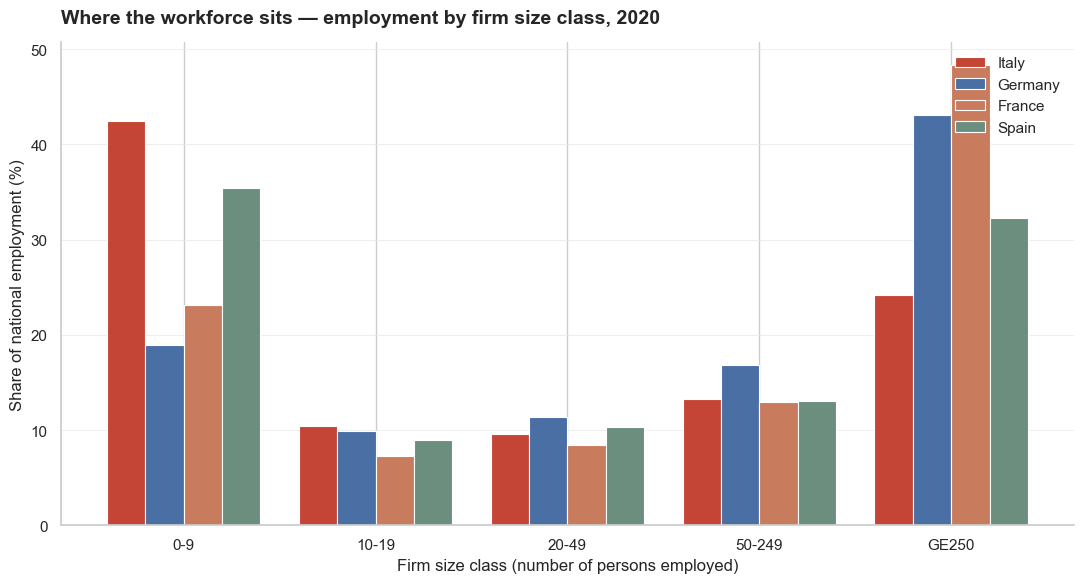

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

countries = ["Italy", "Germany", "France", "Spain"]
country_colors = {"Italy": "#c44536", "Germany": "#4a6fa5", "France": "#c97c5d", "Spain": "#6b8e7f"}

x = np.arange(len(size_order))
width = 0.20

for i, c in enumerate(countries):
    sub = panel[panel["country"] == c].sort_values("size_class")
    ax.bar(x + i*width - 1.5*width, sub["share_emp"], width,
           label=c, color=country_colors[c],
           edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(size_order)
ax.set_xlabel("Firm size class (number of persons employed)")
ax.set_ylabel("Share of national employment (%)")
ax.set_title("Where the workforce sits — employment by firm size class, 2020", loc="left", pad=14, fontsize=14)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="y", color="#e8e8e8", lw=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.show()

## 6. EDA — productivity by firm size class

The same five firm-size brackets, but now showing average labour productivity (gross value added per worker, k€). Three patterns to look for:

1. Productivity rises with firm size (universal economic pattern).
2. Italy starts lower in the smallest firms — this is the "micro-firms gap".
3. Whether Italy *catches up* in the largest firms or not — measure of whether the gap is purely structural or also includes an Italian large-firm productivity penalty.

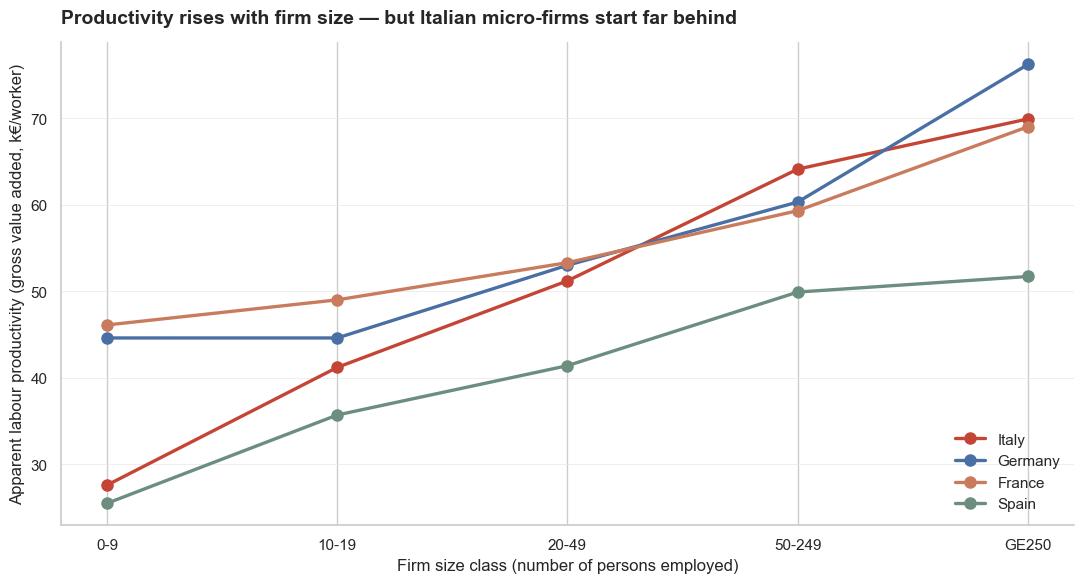

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))

for c in countries:
    sub = panel[panel["country"] == c].sort_values("size_class")
    ax.plot(range(len(size_order)), sub["productivity_kEUR"],
            marker="o", markersize=8, lw=2.4,
            color=country_colors[c], label=c)

ax.set_xticks(range(len(size_order)))
ax.set_xticklabels(size_order)
ax.set_xlabel("Firm size class (number of persons employed)")
ax.set_ylabel("Apparent labour productivity (gross value added, k€/worker)")
ax.set_title("Productivity rises with firm size — but Italian micro-firms start far behind",
             loc="left", pad=14, fontsize=14)
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", color="#e8e8e8", lw=0.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.show()

## 7. EDA prototype — bubble scatter

Before building the final chart, we prototype the two-dimensional intuition with a static bubble scatter. This combines the two dimensions of the story in one plot:

- **X** = average firm size in employees (log scale, so micro and large firms are both legible)
- **Y** = labour productivity (k€ per worker)
- **Bubble area** = share of national employment in that size class
- **Bubble colour** = country

**What we expect to see if the hypothesis holds.** Italy's bubbles cluster low on the X axis (small) *and* low on the Y axis (low productivity), with the largest bubble (highest employment share) in the bottom-left corner. German bubbles sit further right and higher. The visual signature is unmistakable.

This bubble scatter was the analytical step that validated the structural-firm-size hypothesis. It is *not* the final figure. Paper §5 (Rejected alternatives) explains why it was rejected as the published form: too many simultaneous encodings to track, unreliable label positioning under the log scale. The published figure for T3 is the polar Coxcomb chart built in section 10 below.


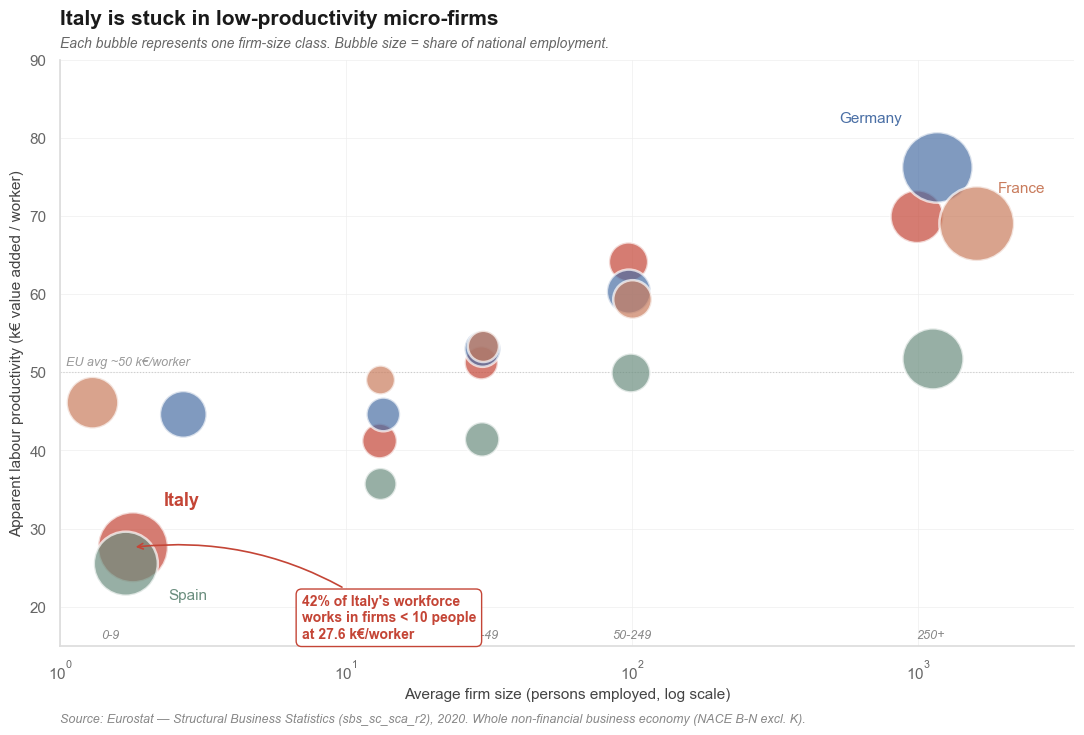

In [8]:
# ---- Project palette (consistent with T1 / T2) ----
COLOR_ITA = "#c44536"   # editorial red for Italy
COLOR_DEU = "#4a6fa5"   # slate blue for Germany
COLOR_FRA = "#c97c5d"   # terracotta for France
COLOR_ESP = "#6b8e7f"   # sage green for Spain

palette = {"Italy": COLOR_ITA, "Germany": COLOR_DEU, "France": COLOR_FRA, "Spain": COLOR_ESP}

# Manual label positions to avoid Italy/Spain overlap in the bottom-left corner
country_labels = {
    "Italy":   {"x": 2.3,  "y": 33, "weight": "bold",     "size": 13},
    "Spain":   {"x": 2.4,  "y": 21, "weight": "regular",  "size": 11},
    "Germany": {"x": 530,  "y": 82, "weight": "regular",  "size": 11},
    "France":  {"x": 1900, "y": 73, "weight": "regular",  "size": 11},
}

fig, ax = plt.subplots(figsize=(11, 7.5))

# European reference line at typical productivity level (~50 k€/worker)
ax.axhline(50, color="#cccccc", lw=0.8, ls=":", zorder=1)
ax.text(1.05, 50.5, "EU avg ~50 k€/worker",
        fontsize=9, color="#999", style="italic", va="bottom")

# Plot bubbles
for c in countries:
    sub = panel[panel["country"] == c].sort_values("size_class")
    ax.scatter(
        sub["avg_size"], sub["productivity_kEUR"],
        s=sub["share_emp"] * 60,
        color=palette[c], alpha=0.7,
        edgecolor="white", linewidth=1.8, zorder=3,
    )

# Direct country labels at fixed positions
for c, props in country_labels.items():
    ax.text(props["x"], props["y"], c,
            fontsize=props["size"], color=palette[c],
            weight=props["weight"], zorder=5)

# Story callout — point to Italy's biggest bubble (the bottom-left corner)
ax.annotate(
    "42% of Italy's workforce\nworks in firms < 10 people\nat 27.6 k€/worker",
    xy=(1.8, 27.6),
    xytext=(7, 16),
    fontsize=10, color=COLOR_ITA, weight="bold",
    arrowprops=dict(arrowstyle="->", color=COLOR_ITA, lw=1.2,
                    connectionstyle="arc3,rad=0.2"),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=COLOR_ITA, lw=1),
    zorder=6,
)

# Title and subtitle
ax.text(0.0, 1.06,
        "Italy is stuck in low-productivity micro-firms",
        transform=ax.transAxes, fontsize=15, weight="bold", color="#1a1a1a")
ax.text(0.0, 1.02,
        "Each bubble represents one firm-size class. Bubble size = share of national employment.",
        transform=ax.transAxes, fontsize=10, color="#666", style="italic")

# Axis size-class reference labels at the bottom
ax.text(1.5, 16, "0-9", fontsize=9, color="#888", ha="center", style="italic")
ax.text(13,  16, "10-19", fontsize=9, color="#888", ha="center", style="italic")
ax.text(30,  16, "20-49", fontsize=9, color="#888", ha="center", style="italic")
ax.text(100, 16, "50-249", fontsize=9, color="#888", ha="center", style="italic")
ax.text(1100,16, "250+",  fontsize=9, color="#888", ha="center", style="italic")

# Axes
ax.set_xscale("log")
ax.set_xlim(1, 3500)
ax.set_ylim(15, 90)
ax.set_xlabel("Average firm size (persons employed, log scale)", fontsize=11, color="#444")
ax.set_ylabel("Apparent labour productivity (k€ value added / worker)", fontsize=11, color="#444")
ax.tick_params(colors="#666")
ax.grid(color="#eee", lw=0.5, zorder=0)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.spines["left"].set_color("#ddd")
ax.spines["bottom"].set_color("#ddd")

# Source caption at bottom
ax.text(0.0, -0.13,
        "Source: Eurostat — Structural Business Statistics (sbs_sc_sca_r2), 2020. Whole non-financial business economy (NACE B-N excl. K).",
        transform=ax.transAxes, fontsize=9, color="#888", style="italic")

plt.tight_layout()
plt.show()

## 8. EDA findings

**Prediction 1 — Italy has more micro-firms.** Italian firms are nearly all micro: about **94 %** of Italian enterprises have fewer than 10 employees. Germany is around **84 %**, France about **95 %**, Spain about **94 %**. So *firm count* is broadly similar across European countries. The first prediction is only weakly supported.

**Prediction 2 — Italian workers are concentrated in micro-firms.** This is where Italy stands out. Italy has **42 %** of its workforce in firms with fewer than 10 employees, vs **19 %** in Germany, **23 %** in France, and **35 %** in Spain. Inversely, only **24 %** of Italian workers are in firms with 250+ employees, vs **43 %** in Germany. **Strongly supported.**

**Prediction 3 — Italian micro-firms are themselves less productive.** In the 0–9 size class, Italian firms generate **27.6 k€** of value added per worker, compared with **44.6 k€** in Germany — a **38 % gap**. The gap narrows in larger firms (only **−8 %** in the 250+ class). **Strongly supported.**

**Synthesis.** Italy faces a *double penalty*: too many workers in micro-firms, *and* its micro-firms are individually less productive than peer micro-firms. The gap with Germany is biggest where Italy is most exposed (in the small-firm strata where most Italians work). This is a structural argument that connects directly to T1: low productivity → low wages.

## 9. Save consolidated panel for downstream use

In [9]:
# No file save: the consolidated firm-size panel lives in memory only.
# The interactive Plotly chart below reads from the SBS tidy CSV directly.


## 10. Final interactive visualisation — *Italy is stuck in low-productivity micro-firms*

The bubble-scatter prototype in section 7 combined four dimensions (firm size, productivity, employment share, country) into a single plot. Reviewing it in context, the chart proved hard to parse: it asks the reader to track multiple encodings at once, and Plotly's annotation positioning under log-scale axes proved unreliable.

We switch instead to a **polar Coxcomb chart** (in the Florence Nightingale rose tradition) that lays out the same data in a more legible structure:

- **Quadrants** are the four countries: Italy at top-right, Germany at top-left, France at bottom-left, Spain at bottom-right.
- **Concentric rings**, from the centre outward, are the five firm-size classes: MICRO (0-9), SMALL (10-19), MEDIUM (20-49), LARGE (50-249), V. LARGE (250+).
- **Radial thickness** of each segment encodes the country's share of employment in that size class. A fat MICRO segment in the Italian quadrant means most Italian workers are in micro-firms.
- **Segment colour** encodes labour productivity (gross value added per worker, k€) on a divergent red-amber-green scale, centred near the European-average level of about 50 k€/worker. A red MICRO segment means low productivity in that class.

The double penalty becomes visually self-evident: Italy's quadrant is fat where it should be thin (bottom of the productivity scale) and red where it should be green. Germany's quadrant is the inverse: thin where it would hurt to be fat, and green where Italy is red.

Click on any country quadrant to drill down into a 360-degree country-only view. The country-filter checkboxes below the chart let the reader limit the comparison to a subset of peers.

**Tool:** Plotly (Python). Output: a self-contained HTML file at `site/viz/t3_italian_nanismo.html`.


In [10]:
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.colors import LinearSegmentedColormap

# ---- Visual identity (consistent with T1 / T2) ----
COLOR_BG_PAPER = "#f8f5ec"
COLOR_TOOLTIP  = "#1a3a5c"
COLOR_INNER    = "#e8e2d4"
COLOR_TEXT     = "#1a1a1a"

country_order = ["Italy", "Germany", "France", "Spain"]
country_centers = {"Italy": 45, "Spain": 315, "Germany": 135, "France": 225}
country_iso     = {"Italy": "ITA", "Germany": "DEU", "France": "FRA", "Spain": "ESP"}

size_order    = ["0-9", "10-19", "20-49", "50-249", "GE250"]
size_descriptors = {"0-9":"MICRO","10-19":"SMALL","20-49":"MEDIUM","50-249":"LARGE","GE250":"V. LARGE"}

# Angular offsets (degrees) applied to each size-class label so the inner thin
# bands (Small/Medium/Large) do not stack radially at the same theta.
SIZE_LABEL_OFFSET = {"0-9": 0, "10-19": -22, "20-49": +22, "50-249": -12, "GE250": +12}

PROD_COLORSCALE = [
    (0.00, "#7f1d1d"), (0.20, "#dc2626"), (0.40, "#fb923c"),
    (0.50, "#fef3c7"), (0.60, "#86efac"), (0.80, "#16a34a"), (1.00, "#14532d"),
]
mpl_cmap = LinearSegmentedColormap.from_list("vivid_rg", PROD_COLORSCALE)
def color_for(prod, vmin=20, vmax=80):
    norm = max(0, min(1, (prod - vmin) / (vmax - vmin)))
    rgba = mpl_cmap(norm)
    return f"rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})"

def text_color_for(prod):
    """White text on dark backgrounds (low or high productivity), dark on mid."""
    return "#ffffff" if (prod < 33 or prod > 65) else "#1a1a1a"

INNER_R = 25.0
TOTAL_R = INNER_R + 100


# ---- Build one Barpolar trace per country (6 bars: country wedge + 5 size classes) ----
fig = go.Figure()

country_label_arrays = {c: {"r": [], "theta": [], "text": [], "color": []}
                         for c in country_order}

for country in country_order:
    sub = panel[panel["country"] == country].set_index("size_class").reindex(size_order)
    theta_c = country_centers[country]

    r_vals    = [INNER_R]
    base_vals = [0.0]
    bar_colors = [COLOR_INNER]
    hover     = [f"<b>{country}</b><br>Click to focus on this country.<br>Click again to reset to all four."]

    cumulative = INNER_R
    for sc in size_order:
        share = float(sub.loc[sc, "share_emp"])
        prod  = float(sub.loc[sc, "productivity_kEUR"])
        r_vals.append(share)
        base_vals.append(cumulative)
        bar_colors.append(color_for(prod))
        hover.append(
            f"<b>{country}</b> · {size_descriptors[sc]} ({sc} employees)<br>"
            f"Share of national employment: <b>{share:.0f}%</b><br>"
            f"Productivity: <b>{prod:.1f} k€/worker</b>"
        )
        # All labels are now shown (no >=8% threshold); the angular stagger
        # below keeps adjacent thin bands' labels from overlapping radially.
        country_label_arrays[country]["r"].append(cumulative + share / 2)
        country_label_arrays[country]["theta"].append(theta_c + SIZE_LABEL_OFFSET[sc])
        country_label_arrays[country]["text"].append(
            f"<b>{size_descriptors[sc]}</b><br>{share:.0f}% · {prod:.0f} k€"
        )
        country_label_arrays[country]["color"].append(text_color_for(prod))
        cumulative += share

    fig.add_trace(go.Barpolar(
        r=r_vals,
        theta=[theta_c] * len(r_vals),
        width=[90] * len(r_vals),
        base=base_vals,
        marker=dict(
            color=bar_colors,
            line=dict(color=COLOR_BG_PAPER, width=1.5),
        ),
        hovertext=hover,
        hoverinfo="text",
        name=country,
        showlegend=False,
    ))


# ---- Traces 4-7: per-country size-class label traces ----
for country in country_order:
    arr = country_label_arrays[country]
    fig.add_trace(go.Scatterpolar(
        r=arr["r"],
        theta=arr["theta"],
        text=arr["text"],
        mode="text",
        textfont=dict(family="Inter, sans-serif", size=11, color=arr["color"]),
        hoverinfo="skip",
        showlegend=False,
        name=f"size-labels-{country}",
    ))


# ---- Traces 8-11: per-country ISO-code labels (one trace per country) ----
for country in country_order:
    fig.add_trace(go.Scatterpolar(
        r=[INNER_R / 2],
        theta=[country_centers[country]],
        text=[f"<b>{country_iso[country]}</b>"],
        mode="text",
        textfont=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
        hoverinfo="skip",
        showlegend=False,
        name=f"iso-{country}",
    ))


# ---- Trace 12: dummy Scatterpolar for the productivity colorbar ----
fig.add_trace(go.Scatterpolar(
    r=[None], theta=[None],
    mode="markers",
    marker=dict(
        colorscale=PROD_COLORSCALE,
        cmin=20, cmax=80,
        color=[50],
        opacity=0,
        showscale=True,
        colorbar=dict(
            title=dict(text="<b>Productivity</b><br><i>k€/worker</i>",
                       font=dict(family="Inter, sans-serif", size=11, color="#1a1a1a"),
                       side="top"),
            tickvals=[20, 35, 50, 65, 80],
            ticktext=["20", "35", "50<br><i>EU avg</i>", "65", "80"],
            tickfont=dict(family="EB Garamond, serif", size=10, color="#666"),
            len=0.55, thickness=14, x=1.02, y=0.5, yanchor="middle",
        ),
    ),
    hoverinfo="skip",
    showlegend=False,
    name="colorbar",
))


fig.update_layout(
    polar=dict(
        bgcolor=COLOR_BG_PAPER,
        radialaxis=dict(range=[0, TOTAL_R], visible=False),
        angularaxis=dict(visible=False, rotation=90, direction="counterclockwise"),
    ),
    title=dict(
        text=("<b>Italian <i>nanismo</i>: a workforce stuck in low-productivity micro-firms</b><br>"
              "<span style='font-family:EB Garamond,serif;font-style:italic;"
              "font-size:13px;color:#666;'>"
              "Each country occupies one quadrant. Within each quadrant, five concentric rings stack outward "
              "from the centre &mdash; <i>micro</i> to <i>very large</i>. <b>Click any country to zoom in</b>; "
              "click again to reset."
              "</span>"),
        x=0.0, y=0.97, xanchor="left",
        font=dict(family="Playfair Display, serif", size=20, color="#1a1a1a"),
    ),
    paper_bgcolor=COLOR_BG_PAPER,
    plot_bgcolor=COLOR_BG_PAPER,
    showlegend=False,
    margin=dict(l=20, r=140, t=110, b=110),
    height=900,
    annotations=[
        dict(
            x=0.0, y=-0.06, xref="paper", yref="paper",
            text=("<b style='color:#c44536;font-size:20px;'>42%</b>"
                  "<span style='font-size:13px;color:#1a1a1a;'>"
                  " of Italy's workforce works in micro-firms that produce only "
                  "<b>28 k€/worker</b> — barely 60% of what equivalent German micro-firms produce."
                  "</span>"),
            showarrow=False, align="left", xanchor="left", yanchor="top",
            font=dict(family="Inter, sans-serif"),
        ),
        dict(
            x=0.0, y=-0.13, xref="paper", yref="paper",
            text=("Source: Eurostat — Structural Business Statistics "
                  "(<i>sbs_sc_sca_r2</i>), 2020. Whole non-financial business "
                  "economy (NACE B-N excl. K). Country labels: "
                  "<b>ITA</b> = Italy, <b>DEU</b> = Germany, <b>FRA</b> = France, <b>ESP</b> = Spain."),
            showarrow=False, align="left", xanchor="left", yanchor="top",
            font=dict(family="EB Garamond, serif", size=10, color="#888"),
        ),
    ],
    hoverlabel=dict(bgcolor=COLOR_TOOLTIP, bordercolor=COLOR_TOOLTIP,
                    font=dict(family="Inter, sans-serif", size=12, color="white")),
)

fig.show()


## 11. Export to standalone HTML

In [11]:
VIZ_OUT = Path("site/viz/t3_italian_nanismo.html")
VIZ_OUT.parent.mkdir(parents=True, exist_ok=True)

pio.write_html(
    fig, str(VIZ_OUT),
    include_plotlyjs="cdn",
    full_html=True,
    config={"displayModeBar": False, "responsive": True},
)

# ---- v6: country filter checkboxes + drill-down (state machine) ----
# Trace numbering (must match cell 17):
#   0..3   → 4 country Barpolar traces (Italy, Germany, France, Spain)
#   4..7   → 4 size-class label Scatterpolar traces (one per country)
#   8..11  → 4 ISO-code label traces (one per country, inside the inner ring)
#   12     → colorbar dummy
#
# State: { filterSet: Set<countryIndex>, focused: countryIndex | null }
#   - filterSet → which countries the user wants to see (checkboxes)
#   - focused   → which country is drill-zoomed (null = no zoom)
# When focused !== null: only `focused` is shown at width=360°, theta=180°.
# Else: all countries in filterSet are shown, evenly distributed.
#   N visible → width=360/N each, centers at width/2 + i*width.
#   Size-class label angular offsets scaled by (new_width / 90).
postmsg_script = """
<style>
.t3-filter {
    font-family: 'Inter', sans-serif;
    font-size: 13px;
    color: #1a1a1a;
    padding: 14px 24px 8px 24px;
    background: #f8f5ec;
    border-bottom: 1px solid #ececec;
    display: flex;
    align-items: center;
    flex-wrap: wrap;
    gap: 4px 4px;
}
.t3-filter-label {
    font-weight: 600;
    margin-right: 14px;
    color: #555;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    font-size: 11px;
}
.t3-filter label {
    margin-right: 14px;
    cursor: pointer;
    user-select: none;
    font-size: 13px;
    color: #1a1a1a;
}
.t3-filter input[type=checkbox] {
    margin-right: 5px;
    cursor: pointer;
    accent-color: #1a3a5c;
    transform: translateY(1px);
}
.t3-filter button {
    margin-left: auto;
    padding: 4px 12px;
    font-size: 11px;
    background: transparent;
    border: 1px solid #d0d0d0;
    border-radius: 4px;
    color: #666;
    cursor: pointer;
    font-family: 'Inter', sans-serif;
    text-transform: uppercase;
    letter-spacing: 0.04em;
}
.t3-filter button:hover { background: #1a3a5c; color: #fff; border-color: #1a3a5c; }
</style>

<div class="t3-filter">
    <span class="t3-filter-label">Show countries:</span>
    <label><input type="checkbox" data-country="0" checked> Italy</label>
    <label><input type="checkbox" data-country="1" checked> Germany</label>
    <label><input type="checkbox" data-country="2" checked> France</label>
    <label><input type="checkbox" data-country="3" checked> Spain</label>
    <button id="t3-reset">Reset all</button>
</div>

<script>
(function () {
    function attach() {
        var gd = document.querySelector('.js-plotly-plot, .plotly-graph-div');
        if (!gd || typeof gd.on !== 'function' || !window.Plotly) return setTimeout(attach, 80);

        var COUNTRY_TRACES    = [0, 1, 2, 3];
        var SIZE_LABEL_TRACES = [4, 5, 6, 7];
        var ISO_LABEL_TRACES  = [8, 9, 10, 11];
        // Size-class angular offsets (degrees) for a 90°-wide quadrant.
        // Order matches size_order = ["0-9","10-19","20-49","50-249","GE250"].
        // Same values used in cell 17's SIZE_LABEL_OFFSET dict.
        var ORIG_OFFSETS = [0, -22, 22, -12, 12];
        var ORIG_WIDTH   = 90;

        var state = {
            filterSet: new Set([0, 1, 2, 3]),
            focused:   null,
        };

        function computePositions() {
            // Returns { visible: [idx,...], widthPer, thetaFor: {idx: theta} }.
            if (state.focused !== null) {
                var pos = {};
                pos[state.focused] = 180;
                return { visible: [state.focused], widthPer: 360, thetaFor: pos };
            }
            var vis = COUNTRY_TRACES.filter(function (i) { return state.filterSet.has(i); });
            if (vis.length === 0) return null;
            var N = vis.length;
            var w = 360 / N;
            var thetaFor = {};
            for (var i = 0; i < N; i++) {
                thetaFor[vis[i]] = (w / 2 + i * w) % 360;
            }
            return { visible: vis, widthPer: w, thetaFor: thetaFor };
        }

        function applyState() {
            var p = computePositions();
            if (!p) return;
            var visible = p.visible, widthPer = p.widthPer, thetaFor = p.thetaFor;
            var scale = widthPer / ORIG_WIDTH;
            var scaledOffsets = ORIG_OFFSETS.map(function (o) { return o * scale; });

            // ---- Country bars: each trace has 6 theta/width values (1 inner + 5 size classes) ----
            var visArr   = [false, false, false, false];
            var widthArr = [null,  null,  null,  null];
            var thetaArr = [null,  null,  null,  null];
            visible.forEach(function (idx) {
                visArr[idx]   = true;
                widthArr[idx] = [widthPer, widthPer, widthPer, widthPer, widthPer, widthPer];
                var t = thetaFor[idx];
                thetaArr[idx] = [t, t, t, t, t, t];
            });
            for (var j = 0; j < 4; j++) {
                if (widthArr[j] === null) widthArr[j] = [90, 90, 90, 90, 90, 90];
                if (thetaArr[j] === null) thetaArr[j] = [0, 0, 0, 0, 0, 0];
            }
            Plotly.restyle(gd, {
                visible: visArr, width: widthArr, theta: thetaArr,
            }, COUNTRY_TRACES);

            // ---- Size-class label traces: each has 5 thetas (one per size class) ----
            var labelVisArr   = [false, false, false, false];
            var labelThetaArr = [null,  null,  null,  null];
            visible.forEach(function (idx) {
                labelVisArr[idx] = true;
                var c = thetaFor[idx];
                labelThetaArr[idx] = scaledOffsets.map(function (o) { return c + o; });
            });
            for (var k = 0; k < 4; k++) {
                if (labelThetaArr[k] === null) labelThetaArr[k] = [0, 0, 0, 0, 0];
            }
            Plotly.restyle(gd, {
                visible: labelVisArr, theta: labelThetaArr,
            }, SIZE_LABEL_TRACES);

            // ---- ISO label traces: each has 1 theta = country centre ----
            var isoVisArr   = [false, false, false, false];
            var isoThetaArr = [null,  null,  null,  null];
            visible.forEach(function (idx) {
                isoVisArr[idx]   = true;
                isoThetaArr[idx] = [thetaFor[idx]];
            });
            for (var m = 0; m < 4; m++) {
                if (isoThetaArr[m] === null) isoThetaArr[m] = [0];
            }
            Plotly.restyle(gd, {
                visible: isoVisArr, theta: isoThetaArr,
            }, ISO_LABEL_TRACES);
        }

        // ---- Click on a country to drill-zoom; click again to reset ----
        gd.on('plotly_click', function (data) {
            if (!data || !data.points || !data.points.length) return;
            var clicked = data.points[0].curveNumber;
            if (COUNTRY_TRACES.indexOf(clicked) === -1) return;
            if (!state.filterSet.has(clicked)) return;
            state.focused = (state.focused === clicked) ? null : clicked;
            applyState();
        });

        // ---- Checkbox handler: toggle filter set ----
        document.querySelectorAll('.t3-filter input[type=checkbox]').forEach(function (cb) {
            cb.addEventListener('change', function () {
                var idx = parseInt(cb.dataset.country, 10);
                if (cb.checked) {
                    state.filterSet.add(idx);
                } else {
                    if (state.filterSet.size === 1) {
                        // Don't allow zero countries; bounce the click.
                        cb.checked = true;
                        return;
                    }
                    state.filterSet.delete(idx);
                    if (state.focused === idx) state.focused = null;
                }
                state.focused = null;  // toggling filter clears drill-down
                applyState();
            });
        });

        // ---- Reset button: restore default 4-country view ----
        var resetBtn = document.getElementById('t3-reset');
        if (resetBtn) {
            resetBtn.addEventListener('click', function () {
                state.filterSet = new Set([0, 1, 2, 3]);
                state.focused   = null;
                document.querySelectorAll('.t3-filter input[type=checkbox]').forEach(function (cb) {
                    cb.checked = true;
                });
                applyState();
            });
        }
        // Initial state (N=4) already matches what cell 17 baked in — no need to applyState() now.
    }
    attach();
})();
</script>
"""

_html = VIZ_OUT.read_text()
# Inject filter UI right after <body> (so it appears above the chart)
_html = _html.replace("<body>", "<body>" + postmsg_script.split("<script>")[0], 1)
# Inject the script just before </body>
_script_only = "<script>" + postmsg_script.split("<script>", 1)[1]
_html = _html.replace("</body>", _script_only + "</body>")
VIZ_OUT.write_text(_html)

print(f"Saved: {VIZ_OUT}")
print(f"Size: {VIZ_OUT.stat().st_size / 1024:.1f} KB")
print("v6: filter checkboxes + drill-down. Selected countries redistribute around the circle.")

# --- centre the chart div within its iframe (post-processing) ---
_centering_css = (
    "<style>\n"
    "  html, body { margin: 0; padding: 0; }\n"
    "  .plotly-graph-div { margin: 0 auto !important; }\n"
    "</style>\n"
)
_html = open(str(VIZ_OUT)).read()
if "plotly-graph-div { margin: 0 auto" not in _html:
    _html = _html.replace("</head>", "</head>\n" + _centering_css)
    open(str(VIZ_OUT), "w").write(_html)



Saved: site/viz/t3_italian_nanismo.html
Size: 28.3 KB
v6: filter checkboxes + drill-down. Selected countries redistribute around the circle.


## 12. T3 deliverable summary — key numbers and artefacts

This section is the *final reference card* for T3, capturing every number, finding, and file path needed for the paper, the AI appendix, the oral defence, and any future iteration. Anyone (including a collaborator who hasn't read the rest of the notebook) should be able to lift T3's narrative directly from this section.

### 12.1 Headline finding

> **42 % of Italy's workforce works in firms with fewer than 10 employees, where productivity is only 27.6 k€/worker — barely 60 % of what equivalent German micro-firms produce.**

This is the *killer fact*. It is what the chart visualises and what the article quotes. It combines two structural disadvantages of the Italian economy in one sentence: (i) too many workers in micro-firms, (ii) Italian micro-firms are themselves less productive than peer micro-firms.

### 12.2 Country-level totals (national averages)

| Country | Total enterprises | Total persons employed | Average productivity (k€/worker) |
|---|---:|---:|---:|
| Italy   | 3 640 489 | 14 914 494 | **46.4** |
| Germany | 2 485 804 | 29 430 780 | **61.8** |
| France  | 3 084 048 | 16 235 541 | **59.7** |
| Spain   | 2 683 786 | 12 510 252 | **39.7** |

National averages tell us Italy sits between France and Spain — closer to Spain on aggregate. The size-class breakdown reveals *why*.

### 12.3 Distribution of national employment by firm-size class (the strip widths)

| Country | 0–9 (MICRO) | 10–19 (SMALL) | 20–49 (MEDIUM) | 50–249 (LARGE) | 250+ (V.LARGE) |
|---|---:|---:|---:|---:|---:|
| **Italy**   | **42 %** | 10 % | 10 % | 13 % | 24 % |
| Germany     | 19 %     | 10 % | 11 % | 17 % | **43 %** |
| France      | 23 %     |  7 % |  8 % | 13 % | **48 %** |
| Spain       | **35 %** |  9 % | 10 % | 13 % | 32 % |

Italy is the only country where MICRO is the largest segment. Spain is second-most "front-heavy". Germany and France are both back-heavy — the bulk of their workforce is in firms with 250 or more employees.

### 12.4 Productivity by firm-size class (the strip colours)

Apparent labour productivity (gross value added per worker, in k€), 2020:

| Country | 0–9 | 10–19 | 20–49 | 50–249 | 250+ |
|---|---:|---:|---:|---:|---:|
| Italy   | **27.6** | 41.2 | 51.2 | **64.1** | 69.9 |
| Germany | 44.6 | 44.6 | 53.0 | 60.3 | **76.2** |
| France  | 46.1 | 49.0 | 53.3 | 59.3 | 69.0 |
| Spain   | 25.5 | 35.7 | 41.4 | 49.9 | 51.7 |

Three patterns to note for the paper:

1. **Italy's micro-firms are 38 % less productive than Germany's micro-firms** (27.6 vs 44.6). This is the largest country gap in any size class.
2. **Italy's medium firms (50–249) actually outperform Germany's** (64.1 vs 60.3). The Italian disadvantage is concentrated in the smallest firms, not in mid-sized ones.
3. **Italian large firms (250+) trail Germany by 8 %** (69.9 vs 76.2) — meaningful but not extreme.

The asymmetric productivity gap — wide at the small end, narrow elsewhere — is the structural explanation for low Italian aggregate productivity.

### 12.5 Median country growth, 2000 → 2024 (cross-reference with T2)

For continuity with T2's narrative:

| Country | Median regional growth in PPS per capita |
|---|---|
| Italy | +70 % |
| France | +81 % |
| Spain | +99 % |
| Germany | +101 % |
| EA20 average | +99 % |

Italy is the slowest grower among Western European peers, by a wide margin. T3 explains *why*: the structure of firms.

### 12.6 The "European patterns" finding (bonus narrative)

The four strips reveal **two opposite economic models**, not just an Italian outlier:

- **"Mediterranean fragmentation" model** (Italy, Spain): front-heavy strips with large dark-red segments at the MICRO end. High share of workforce in low-productivity small firms.
- **"Continental concentration" model** (Germany, France): back-heavy strips with large dark-green segments at the V.LARGE end. High share of workforce in high-productivity large firms.

Italy is the most extreme case of the Mediterranean pattern; Germany is the most extreme case of the Continental pattern. This framing is more nuanced than "Italy vs Germany" and could be a paragraph in the paper. France and Spain are the moderate cases of each pattern.

### 12.7 Saved artefacts

**Data**
- `data/task_3/sbs_size_class_eurostat_2020_tidy.csv` (24 rows, one per country × size class).
- `data/task_3/SOURCES.md` (full documentation of provenance, filters, and known limitations).

The intermediate panel with derived metrics (`share_emp`, `share_firms`, `productivity_kEUR`, `avg_size`) is computed in section 4 of this notebook and lives in memory only; it is not persisted as a separate file.

**Final deliverable for the website**
- `site/viz/t3_italian_nanismo.html` — **interactive Plotly chart** embedded into `site/index.html` under the "Why the Engine Stopped" section. The chart is a custom mosaic-strip visualisation: one strip per country, segmented by firm-size class, with width = share of national employment and colour = productivity. Includes legend (color scale + cell anatomy diagram), big callout, direction arrow, and narrative hook. ~42 KB; loads Plotly runtime from CDN.

### 12.8 Methodological notes for the paper / oral defence

Three things to flag honestly in the paper's *Limitations* section:

1. **Year is 2020 (latest legacy SBS data)**, which includes COVID effects. The structural composition of firms is slow-moving and the COVID year does not meaningfully distort firm-size shares; productivity values for some sectors may be slightly affected. Eurostat's new EBS framework hadn't yet published a comparable size-class breakdown at the time of analysis.
2. **Wages by size class are not published by Eurostat** for our country panel (variables V13320, V13310, V91230 all confidentiality-suppressed). The wage angle is therefore picked up from T1 in the paper's prose: low Italian micro-firm productivity → low Italian micro-firm wages → contributes to the aggregate wage stagnation documented in T1.
3. **Correlation, not causation.** The chart establishes that small Italian firms are also less productive than peer small firms, but does not prove that firm size *causes* low productivity. Italy's structure may itself be the consequence of other constraints (financing, regulation, demographic). The paper acknowledges this and cites supporting work (Banca d'Italia 2018, OECD 2019) that develops the causal argument.